<a href="https://colab.research.google.com/github/FideliaOsei/cs666student/blob/main/Copy_of_CS666_Assignment_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

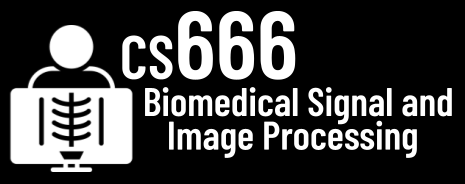
#Assignment 6

In [97]:
# NAME:Fidelia Darkoa Osei

In [98]:
# In this assignment, we will visualize and explore a CT scan!

In [99]:
# load numpy and matplotlib
%pylab inline

Populating the interactive namespace from numpy and matplotlib


In [100]:
# we are using pydicom, so lets install it!
!pip install pydicom

**Task 1**: Download and visualize data with SliceDrop! [20 Points]

In [101]:
# Use wget to download https://cs666.org/data/ct.zip!
# This is a CT scan of an arm in DICOM format.

In [102]:
# TODO: YOUR CODE

In [103]:
!wget https://cs666.org/data/ct.zip

--2026-05-06 18:44:32--  https://cs666.org/data/ct.zip
Resolving cs666.org (cs666.org)... 185.199.110.153, 185.199.111.153, 185.199.108.153, ...
Connecting to cs666.org (cs666.org)|185.199.110.153|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5847706 (5.6M) [application/x-zip-compressed]
Saving to: ‘ct.zip.2’

ct.zip.2            100%[===================>]   5.58M  --.-KB/s    in 0.08s   

2026-05-06 18:44:32 (69.8 MB/s) - ‘ct.zip.2’ saved [5847706/5847706]



In [104]:
# Then use the following snippet to extract the data.

In [105]:
import zipfile
with zipfile.ZipFile('ct.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

In [106]:
import os

DIR = "ct"

dcm_files = [f for f in os.listdir(DIR) if f.endswith('.dcm')]

print("Number of slices:", len(dcm_files))

Number of slices: 220


In [107]:
# 1) Let's explore the data using the Files panel on the left.
# TODO: How many slices are there?

In [108]:
# TODO: YOUR_ANSWER

There are 220 slices

In [109]:
# 2) Let's visualize the data with SliceDrop!
# Go to https://slicedrop.com and drag'n'drop all .dcm files into the browser.
# Please use the 2D sliders to show axial, sagittal, and coronal slices in 3D.

In [110]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click. This should not be volume
# rendering but show the 3 cross sections.

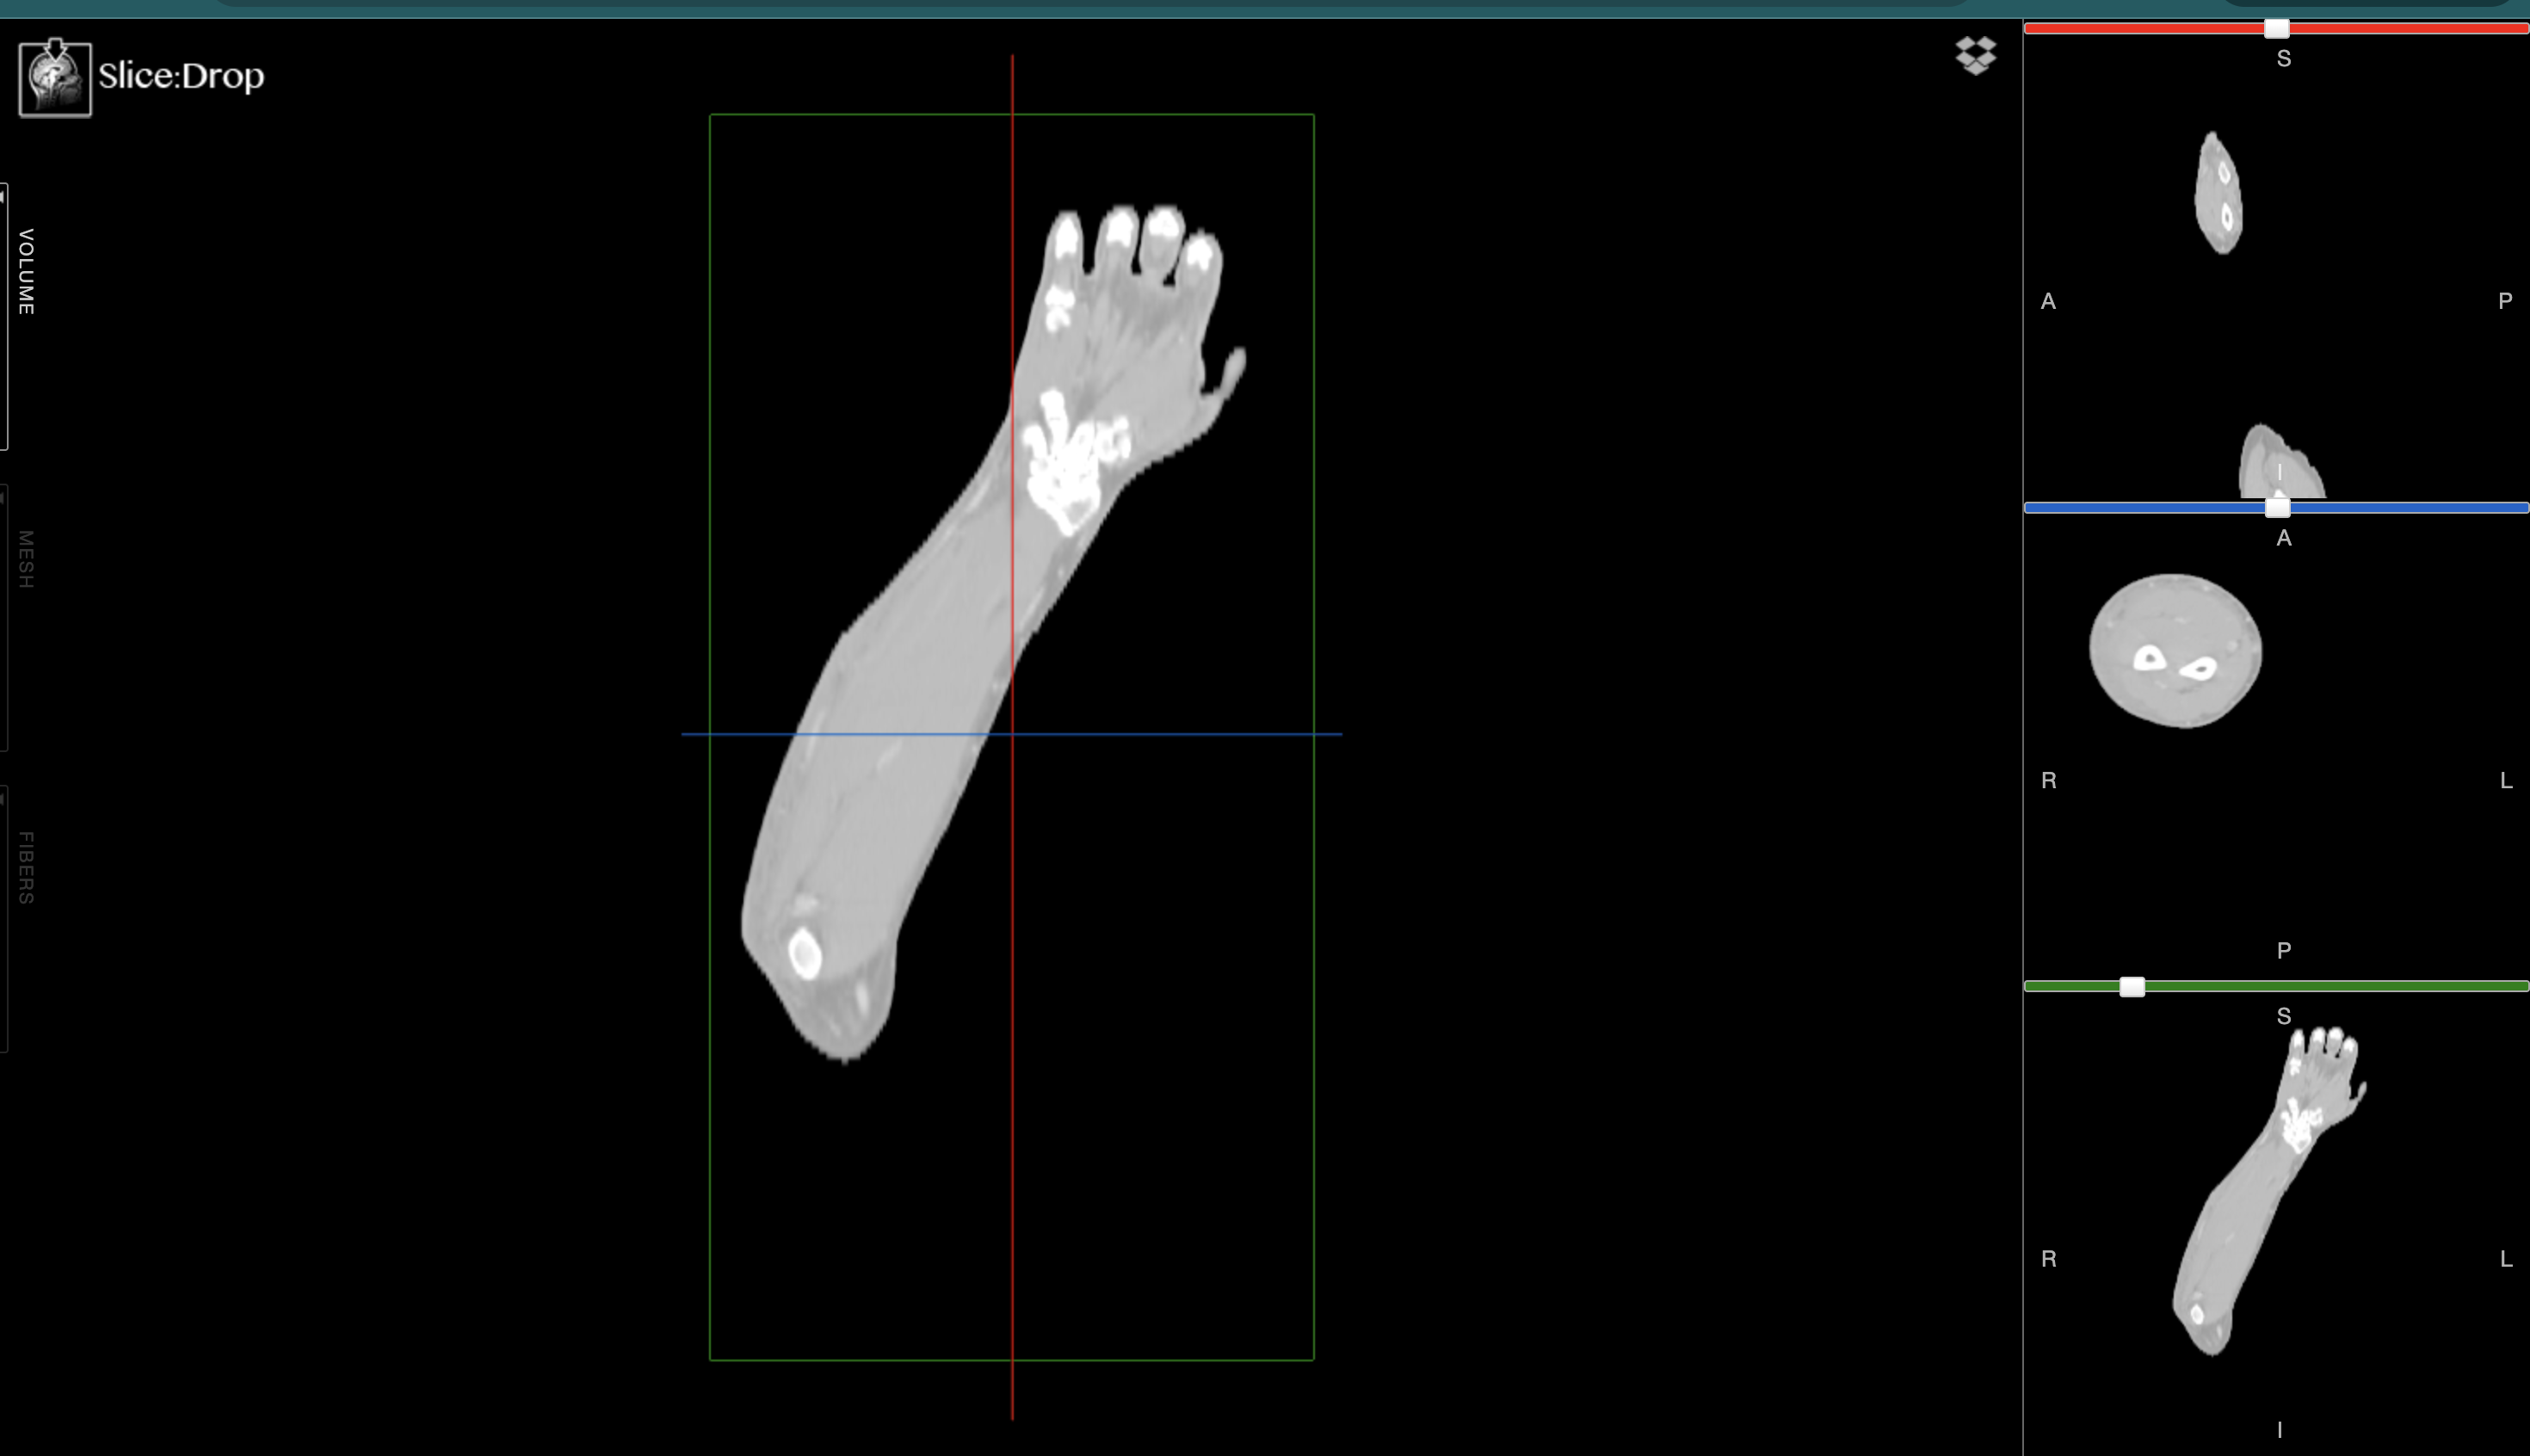

In [111]:
# 3) Let's visualize only the bones! Please use the thresholding
# based on a window suitable for bones and show a 3D volume rendering.

In [112]:
# TODO Please post a screenshot of SliceDrop's 3D View in the text box below by
# using the Upload image button after double-click.

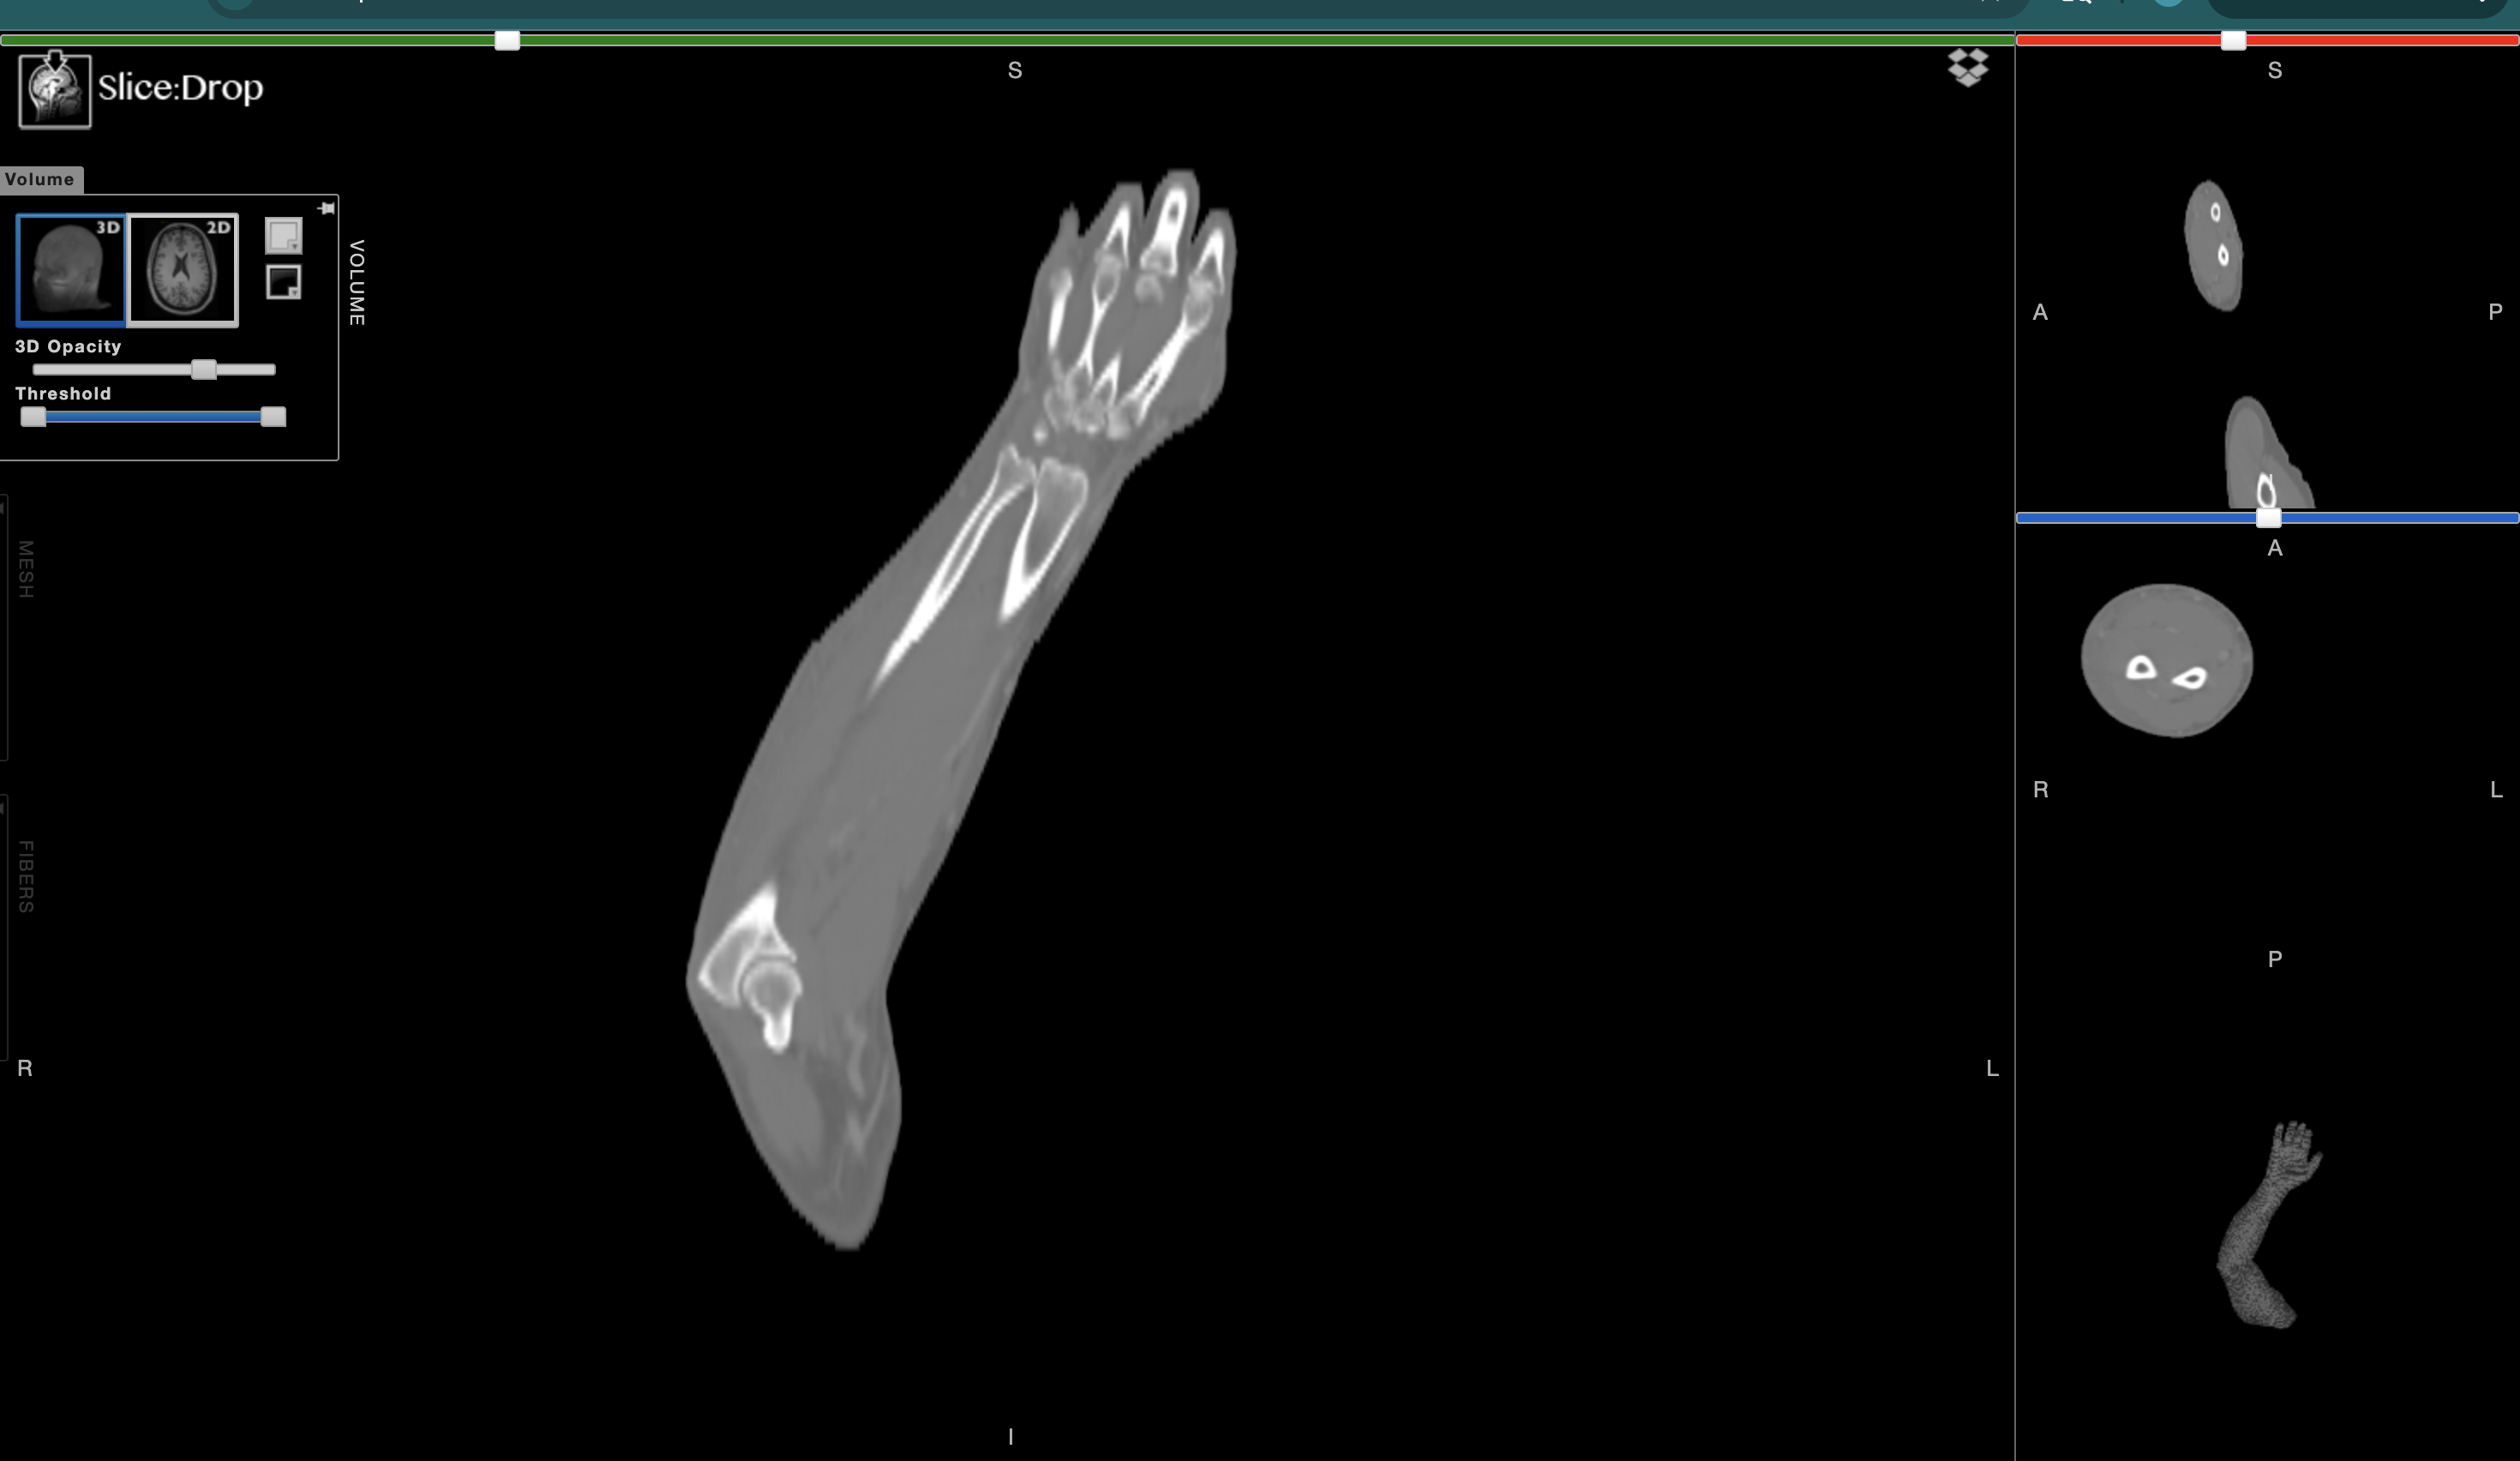

**Task 2**: Load the data using pydicom as a 3D volume and then reslice it! [35 Points]

In [113]:
# 1) Now loop through all the DICOM files and store them in a 3D numpy array.
# Hint: You can either store them in a list first or read the dimensions of a
# single image slice to properly create the 3D numpy array.
# Hint 2: os.listdir(DIR) gives a list of filenames in a directory.
# Hint 2b: This list is not sorted - make sure you sort it.
# Hint 3: The dcmread function loads a single DICOM file.
# Hint 4: You can then use .pixel_array to access the image data.

In [114]:
#from pydicom import dcmread

In [115]:
# TODO: YOUR CODE FOR LOADING THE VOLUME AS A 3D NUMPY ARRAY

In [116]:
import os
import numpy as np
from pydicom import dcmread

DIR = "ct"

files = sorted([f for f in os.listdir(DIR) if f.endswith(".dcm")])

slices = []

for f in files:
    path = os.path.join(DIR, f)
    ds = dcmread(path)
    slices.append(ds.pixel_array)

volume = np.array(slices)

print("Volume shape:", volume.shape)

Volume shape: (220, 454, 512)


In [117]:
# 2) Now create and show axial, sagittal, and coronal slices from the 3D volume.
# Hint: Please use imshow(XX, cmap='gray') to show the image.

In [118]:
# TODO: YOUR CODE FOR AXIAL

Text(0.5, 1.0, 'Axial Slice')

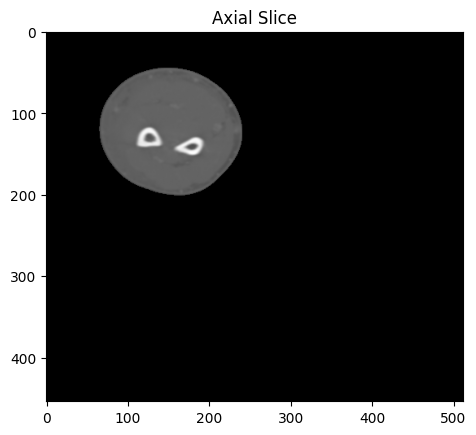

In [119]:
imshow(volume[volume.shape[0] // 2, :, :], cmap='gray')
title("Axial Slice")

In [120]:
# TODO: YOUR CODE FOR SAGITTAL

Text(0.5, 1.0, 'Sagittal Slice')

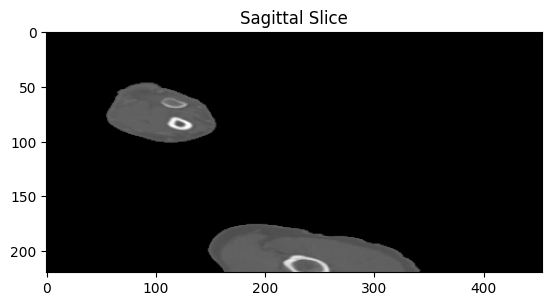

In [121]:
imshow(volume[:, :, volume.shape[2] // 2], cmap='gray')
title("Sagittal Slice")

In [122]:
# TODO: YOUR CODE FOR CORONAL

Text(0.5, 1.0, 'Coronal Slice')

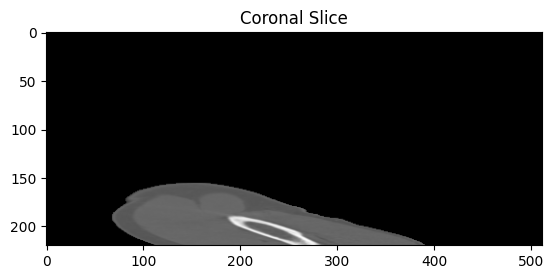

In [123]:
imshow(volume[:, volume.shape[1] // 2, :], cmap='gray')
title("Coronal Slice")

**Task 3**: Use the Window/Level-technique to visualize the data! [45 Points]

In [124]:
# We will now enhance the visualization from above by performing
# Window/Level adjustment.
# Here is one way of doing that:
#   vmin = level - window/2
#   vmax = level + window/2
#   plt.imshow(hu_pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
#   plt.show()

In [125]:
# 1) Please load the Window/Level values from the DICOM file,
# print these values, and then visualize one slice with window/level adjustment.
# Hint: The DICOM header has the following tags.
#   (0028, 1050) Window Center
#   (0028, 1051) Window Width
# Hint 2: You can use slice[key].value to access DICOM tag values.
# Hint 3: (0028, 1052) Rescale Intercept might be important.

In [126]:
# TODO: YOUR CODE

Window Width: 410
Window Center: 30
Rescale Intercept: -1024


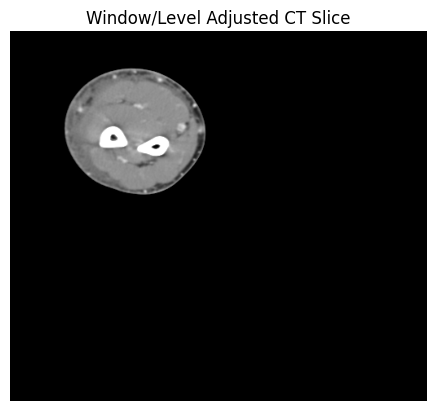

In [127]:
import matplotlib.pyplot as plt

# Use one middle DICOM slice
ds = dcmread(os.path.join(DIR, files[len(files)//2]))

pixels = ds.pixel_array.astype(float)

window = ds[(0x0028, 0x1051)].value   # Window Width
level = ds[(0x0028, 0x1050)].value    # Window Center
rescale = ds[(0x0028, 0x1052)].value  # Rescale Intercept

print("Window Width:", window)
print("Window Center:", level)
print("Rescale Intercept:", rescale)

vmin = level - window/2
vmax = level + window/2

plt.imshow(pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Window/Level Adjusted CT Slice")
plt.axis("off")
plt.show()

In [128]:
# 2) Play around with different Window/Level values that enhance
# the visualization.

In [129]:
# TODO: YOUR CODE

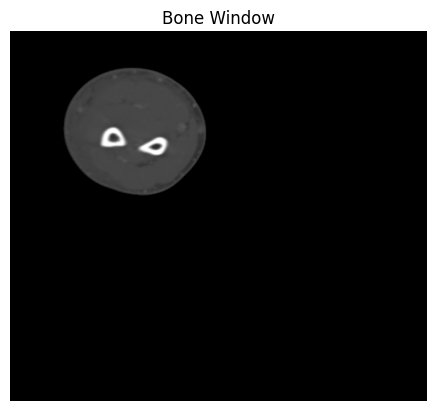

In [130]:
window = 2000
level = 500

vmin = level - window/2
vmax = level + window/2

plt.imshow(pixels + rescale, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("Bone Window")
plt.axis("off")
plt.show()

In [131]:
# Which values make sense and why?

In [132]:
# TODO: YOUR ANSWER

The default window (width=410, center=30) is suitable for soft tissue, allowing us to see the overall structure of the arm and surrounding tissue.

A larger window and higher level (e.g., width=2000, center=500) is better for bones, because bone has higher intensity (HU values). This window enhances bright structures and suppresses soft tissue, making the bones more visible.

Therefore, different window/level settings are used depending on what structures (soft tissue vs bone) we want to visualize.

**Bonus**: Create segmentations (label maps) for the volume using thresholding HU! [33 Points]

In [133]:
# Similar to Window/Level adjustment for visualization, we can threshold
# the volume to highlight the following components using the Hounsfield Units:
# 1) Fat
# 2) Soft Tissue
# 3) Bones
#
# Please create 3 segmentation masks for these structures.
# Then, please visualize each 3 slices per structure to showcase the segmentation.
# Hint: As a reminder, the following code allows thresholding of a numpy array.
#   new_mask = imagevolume.copy()
#   new_mask[new_mask < XXX] = 0
# Hint2: You might need to cast new_mask to int16 not uint16.

In [134]:
# TODO: YOUR CODE TO SEGMENT FAT

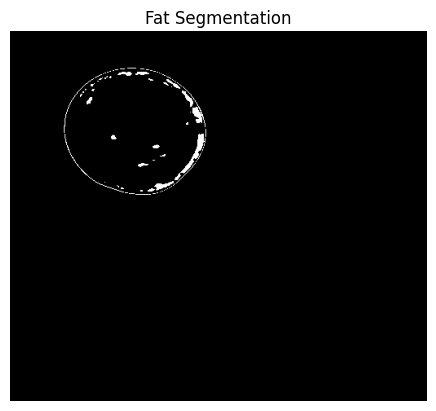

In [135]:
hu_volume = volume.astype(np.int16) + rescale

fat_mask = np.zeros_like(hu_volume, dtype=np.uint8)
fat_mask[(hu_volume >= -190) & (hu_volume <= -30)] = 1

plt.imshow(fat_mask[fat_mask.shape[0]//2], cmap='gray')
plt.title("Fat Segmentation")
plt.axis("off")
plt.show()

In [136]:
# TODO: YOUR CODE TO SEGMENT SOFT TISSUE

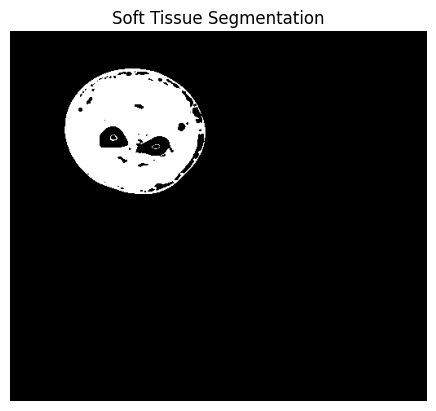

In [137]:
soft_tissue_mask = np.zeros_like(hu_volume, dtype=np.uint8)
soft_tissue_mask[(hu_volume >= -30) & (hu_volume <= 100)] = 1

plt.imshow(soft_tissue_mask[soft_tissue_mask.shape[0]//2], cmap='gray')
plt.title("Soft Tissue Segmentation")
plt.axis("off")
plt.show()

In [138]:
# TODO: YOUR CODE TO SEGMENT BONES

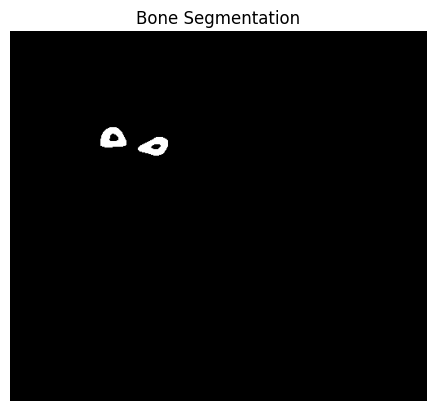

In [139]:
bone_mask = np.zeros_like(hu_volume, dtype=np.uint8)
bone_mask[hu_volume >= 300] = 1

plt.imshow(bone_mask[bone_mask.shape[0]//2], cmap='gray')
plt.title("Bone Segmentation")
plt.axis("off")
plt.show()

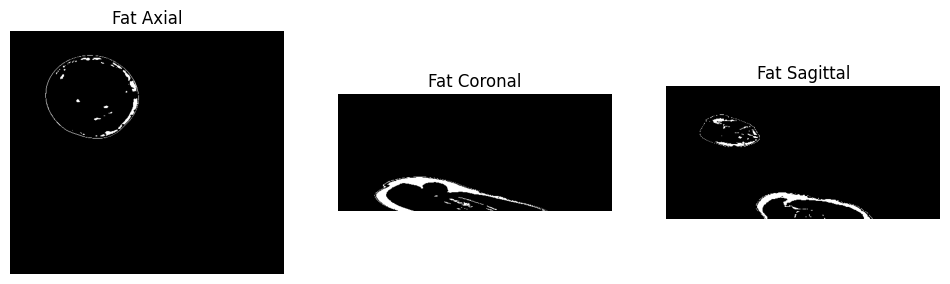

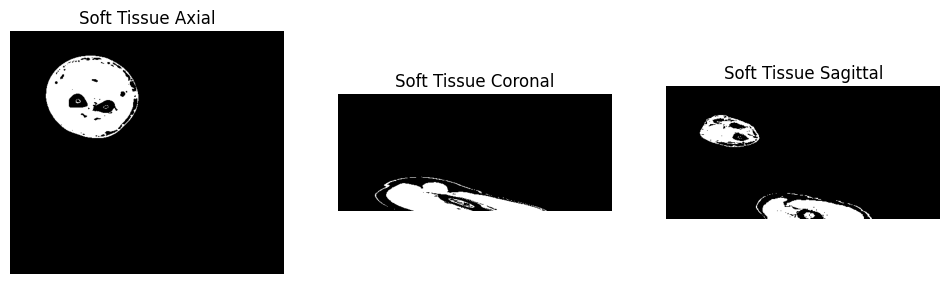

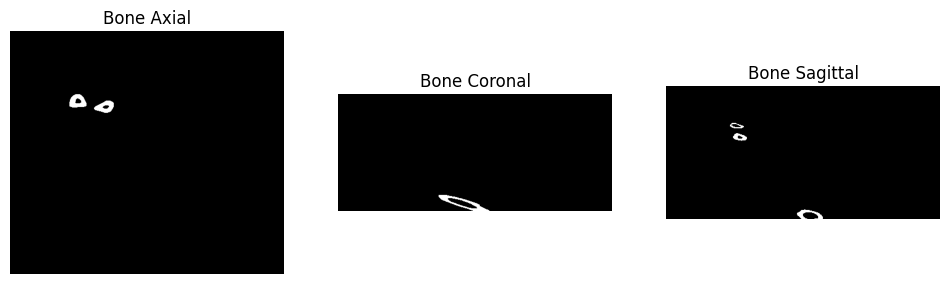

In [140]:
def show_three_slices(mask, title):
    z = mask.shape[0] // 2
    y = mask.shape[1] // 2
    x = mask.shape[2] // 2

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(mask[z, :, :], cmap='gray')
    plt.title(title + " Axial")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask[:, y, :], cmap='gray')
    plt.title(title + " Coronal")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(mask[:, :, x], cmap='gray')
    plt.title(title + " Sagittal")
    plt.axis("off")

    plt.show()

show_three_slices(fat_mask, "Fat")
show_three_slices(soft_tissue_mask, "Soft Tissue")
show_three_slices(bone_mask, "Bone")

In [141]:
# Are the segmentations good?

In [142]:
# TODO: YOUR ANSWER

The segmentations are reasonable but not perfect.
Bone segmentation works well because bones have high Hounsfield Units (HU) values and are easy to separate.
Soft tissue segmentation also captures most of the tissue region, but some overlap exists.
Fat segmentation is noisier because fat HU values can overlap with surrounding tissue and air.
Simple thresholding works for basic separation, but more advanced methods would improve accuracy.

In [143]:
#
# Thank you and Great job!!
#
#                _.---._
#              .'       `.
#              :)       (:
#              \ (@) (@) /
#               \   A   /
#                )     (
#                \"""""/
#                 `._.'
#                  .=.
#          .---._.-.=.-._.---.
#         / ':-(_.-: :-._)-:` \
#        / /' (__.-: :-.__) `\ \
#       / /  (___.-` '-.___)  \ \
#      / /   (___.-'^`-.___)   \ \
#     / /    (___.-'=`-.___)    \ \
#    / /     (____.'=`.____)     \ \
#   / /       (___.'=`.___)       \ \
#  (_.;       `---'.=.`---'       ;._)
#  ;||        __  _.=._  __        ||;
#  ;||       (  `.-.=.-.'  )       ||;
#  ;||       \    `.=.'    /       ||;
#  ;||        \    .=.    /        ||;
#  ;||       .-`.`-._.-'.'-.       ||;
# .:::\      ( ,): O O :(, )      /:::.
# |||| `     / /'`--'--'`\ \     ' ||||
# ''''      / /           \ \      ''''
#          / /             \ \
#         / /               \ \
#        / /                 \ \
#       / /                   \ \
#      / /                     \ \
#     /.'                       `.\
#    (_)'                       `(_)
#     \\.                       .//
#      \\.                     .//
#       \\.                   .//
#        \\.                 .//
#         \\.               .//
#          \\.             .//
#     jgs   \\.           .//
#           ///)         (\\\
#         ,///'           `\\\,
#        ///'               `\\\
#       ""'                   '""